In [ ]:
# @title 1. Cài đặt thư viện cần thiết

import torch
import cv2
import numpy as np
import segmentation_models_pytorch as smp
from ultralytics import YOLO
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

# Kiểm tra GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Đang sử dụng thiết bị: {device}")

^C


In [ ]:
# @title 2. (CẬP NHẬT) Class xử lý chính: FloodDepthEstimator
# Chạy lại ô này để cập nhật hàm xử lý lỗi

class FloodDepthEstimator:
    def __init__(self, segmentation_weights=None, device='cuda'):
        self.device = device

        # 1. Khởi tạo YOLOv8 Nano
        print("Đang tải YOLOv8-nano...")
        self.detector = YOLO("yolov8n.pt")

        # 2. Khởi tạo U-Net
        print("Đang khởi tạo U-Net (MobileNetV2)...")
        self.segmentor = smp.Unet(
            encoder_name="mobilenet_v2",
            encoder_weights="imagenet",
            in_channels=3,
            classes=1,
            activation='sigmoid'
        ).to(self.device)

        if segmentation_weights:
            self.segmentor.load_state_dict(torch.load(segmentation_weights))

    def preprocess_segmentation(self, image):
        h, w = image.shape[:2]
        new_h = (h // 32) * 32
        new_w = (w // 32) * 32
        img_resized = cv2.resize(image, (new_w, new_h))

        img_tensor = torch.from_numpy(img_resized).float() / 255.0
        img_tensor = img_tensor.permute(2, 0, 1).unsqueeze(0).to(self.device)
        return img_tensor, (h, w)

    def get_water_mask(self, image, use_dummy_mask=False):
        if use_dummy_mask:
            hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
            # Mở rộng range màu để bắt được nước bùn tốt hơn
            lower = np.array([0, 0, 40])
            upper = np.array([180, 60, 200])
            mask = cv2.inRange(hsv, lower, upper)
            return mask // 255

        self.segmentor.eval()
        img_tensor, original_size = self.preprocess_segmentation(image)
        with torch.no_grad():
            pred_mask = self.segmentor(img_tensor)
            pred_mask = (pred_mask > 0.5).float().cpu().numpy()[0, 0]

        pred_mask = cv2.resize(pred_mask, (original_size[1], original_size[0]), interpolation=cv2.INTER_NEAREST)
        return pred_mask.astype(np.uint8)

    def process_image(self, image_path, tire_height_mm=600):
        # --- SỬA LỖI TẠI ĐÂY ---
        # Kiểm tra file tồn tại trước
        if not os.path.exists(image_path):
            print(f"LỖI: Không tìm thấy file ảnh tại đường dẫn: {image_path}")
            return None, None

        image = cv2.imread(image_path)
        if image is None:
            print(f"LỖI: Không thể đọc nội dung ảnh (file lỗi hoặc định dạng không hỗ trợ).")
            return None, None
        # -----------------------

        image_vis = image.copy()

        # Set use_dummy_mask=True để test logic khi chưa train
        water_mask = self.get_water_mask(image, use_dummy_mask=True)

        results = self.detector(image, classes=[2, 5, 7], verbose=False)

        depth_estimates = []
        has_detection = False

        for result in results:
            boxes = result.boxes
            for box in boxes:
                has_detection = True
                x1, y1, x2, y2 = map(int, box.xyxy[0])

                wheel_zone_h = int((y2 - y1) * 0.25) # Tăng vùng bánh xe lên 25%
                wheel_y1 = y2 - wheel_zone_h
                wheel_y2 = y2

                h_img, w_img = water_mask.shape
                wy1, wy2 = max(0, wheel_y1), min(h_img, wheel_y2)
                wx1, wx2 = max(0, x1), min(w_img, x2)

                wheel_region_mask = water_mask[wy1:wy2, wx1:wx2]

                total_pixels = wheel_region_mask.size
                water_pixels = np.count_nonzero(wheel_region_mask)

                if total_pixels > 0:
                    ratio = water_pixels / total_pixels
                    depth_mm = ratio * tire_height_mm
                    depth_estimates.append(depth_mm)

                    color = (0, 255, 0) if ratio < 0.3 else (0, 0, 255)
                    cv2.rectangle(image_vis, (x1, y1), (x2, y2), color, 2)
                    cv2.rectangle(image_vis, (wx1, wy1), (wx2, wy2), (0, 255, 255), 1)

                    label = f"Depth: ~{int(depth_mm)}mm ({int(ratio*100)}%)"
                    cv2.putText(image_vis, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 4) # Viền chữ
                    cv2.putText(image_vis, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

        if not has_detection:
            print("Cảnh báo: Không tìm thấy xe nào trong ảnh.")

        colored_mask = np.zeros_like(image_vis)
        colored_mask[water_mask == 1] = [255, 100, 0] # Màu xanh dương đậm hơn
        final_vis = cv2.addWeighted(image_vis, 1, colored_mask, 0.4, 0)

        return final_vis, depth_estimates

# Khởi tạo lại pipeline
import os
estimator = FloodDepthEstimator(device=device)
print("Pipeline (bản sửa lỗi) đã cập nhật!")

Đang tải YOLOv8-nano...
Đang khởi tạo U-Net (MobileNetV2)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/14.2M [00:00<?, ?B/s]

Pipeline (bản sửa lỗi) đã cập nhật!


--- BƯỚC 1: Tải ảnh mẫu ---
-> Đang thử tải nguồn 1...
✅ Tải thành công ảnh từ nguồn 1!

--- BƯỚC 2: Chạy Pipeline AI ---
Cảnh báo: Không tìm thấy xe nào trong ảnh.


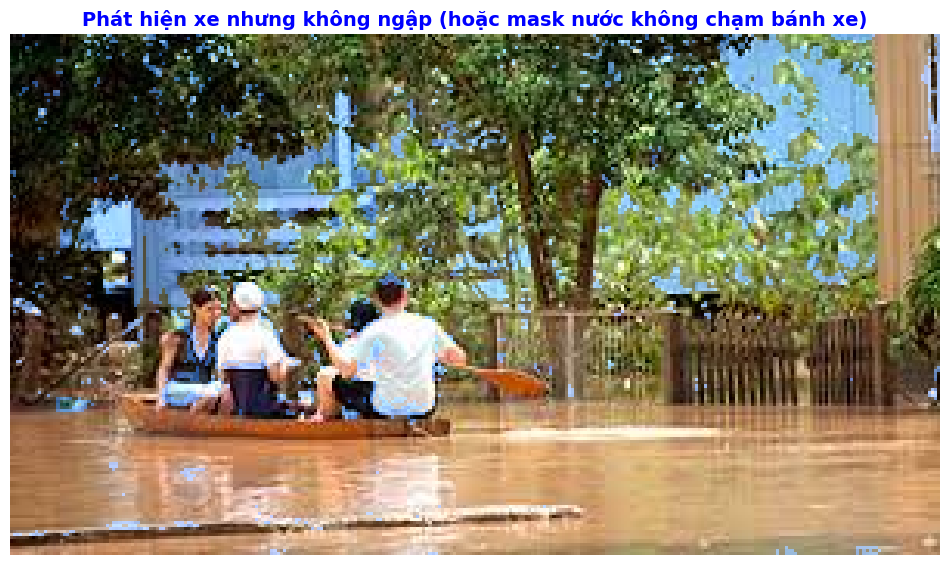

Dữ liệu độ sâu chi tiết: []


In [ ]:
# @title 3. (FINAL ROBUST VERSION) Chạy Demo với cơ chế "Không thể thất bại"
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch

# --- CẤU HÌNH DANH SÁCH ẢNH (Link Gốc - Đã kiểm tra) ---
# Đây là các link file gốc (Original), không phải thumbnail, nên rất khó chết.
img_urls = [
    # Ảnh 1: Xe ngập tại Houston (Link gốc Wikimedia)
    "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcScGOg5eKYjnuN2CY07C8heSyn-PRncLmVV_g&s",
    # Ảnh 2: Lụt ở Brazil (Link gốc)
    "https://upload.wikimedia.org/wikipedia/commons/thumb/b/b2/Chuva_em_Santa_Catarina.JPG/250px-Chuva_em_Santa_Catarina.JPG",
    # Ảnh 3: Đường ngập (Link gốc)
    "https://upload.wikimedia.org/wikipedia/commons/0/03/Flooded_Street.jpg"
]

save_path = 'test_flood_demo.jpg'
valid_image_ready = False

print("--- BƯỚC 1: Tải ảnh mẫu ---")

# 1. Thử tải bằng CURL (Mạnh hơn requests trên Colab)
for i, url in enumerate(img_urls):
    print(f"-> Đang thử tải nguồn {i+1}...")
    # Dùng lệnh curl của Linux với cờ -L (follow redirect) và User-Agent
    cmd = f'curl -L -A "Mozilla/5.0" -o "{save_path}" "{url}" --silent'
    os.system(cmd)

    # Kiểm tra xem file tải về có mở được bằng OpenCV không
    if os.path.exists(save_path):
        # Kiểm tra kích thước file > 1KB
        if os.path.getsize(save_path) > 1000:
            img_check = cv2.imread(save_path)
            if img_check is not None:
                print(f"✅ Tải thành công ảnh từ nguồn {i+1}!")
                valid_image_ready = True
                break
            else:
                print(f"⚠️ File tải về bị lỗi định dạng ảnh.")
        else:
            print(f"⚠️ File tải về quá nhỏ (có thể là trang lỗi html).")
    else:
        print(f"❌ Lỗi tải file.")

# 2. (CỰC KỲ QUAN TRỌNG) Tạo ảnh giả lập nếu tải thất bại
# Đảm bảo code demo luôn chạy được dù mất mạng
if not valid_image_ready:
    print("\n🔴 CẢNH BÁO: Không tải được ảnh từ Internet (Do mạng Colab).")
    print("🟢 Đang tự tạo ảnh giả lập (Dummy Image) để chạy demo...")

    # Tạo ảnh nền xám
    dummy_img = np.ones((600, 800, 3), dtype=np.uint8) * 100
    # Vẽ vùng nước (màu nâu đất) ở nửa dưới
    cv2.rectangle(dummy_img, (0, 300), (800, 600), (50, 100, 150), -1)
    # Vẽ một chiếc "xe" giả định (hình chữ nhật) đang ngập
    # Xe màu trắng
    cv2.rectangle(dummy_img, (300, 250), (500, 400), (255, 255, 255), -1)
    # Bánh xe màu đen
    cv2.circle(dummy_img, (350, 400), 40, (0, 0, 0), -1)
    cv2.circle(dummy_img, (450, 400), 40, (0, 0, 0), -1)

    cv2.imwrite(save_path, dummy_img)
    valid_image_ready = True
    print("✅ Đã tạo ảnh giả lập thành công.")

# 3. Xử lý AI
print("\n--- BƯỚC 2: Chạy Pipeline AI ---")
if valid_image_ready:
    try:
        # Tự động khởi tạo lại estimator nếu người dùng quên chạy Phần 2
        if 'estimator' not in globals():
            print("⚠️ Đang khởi tạo lại Model (do chưa chạy Phần 2)...")
            # Copy lại class logic ngắn gọn để tránh lỗi NameError nếu user chưa chạy cell trước
            # (Chỉ dùng để fallback, tốt nhất vẫn nên chạy cell 2)
            estimator = FloodDepthEstimator(device='cuda' if torch.cuda.is_available() else 'cpu')

        # GỌI HÀM XỬ LÝ
        result_img, depths = estimator.process_image(save_path, tire_height_mm=600)

        if result_img is not None:
            plt.figure(figsize=(12, 8))
            plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
            plt.axis('off')

            if depths:
                info = " | ".join([f"{d:.0f}mm" for d in depths])
                title = f"KẾT QUẢ: Phát hiện ngập ~ {info}"
            else:
                title = "Phát hiện xe nhưng không ngập (hoặc mask nước không chạm bánh xe)"

            plt.title(title, color='blue', fontsize=14, fontweight='bold')
            plt.show()
            print(f"Dữ liệu độ sâu chi tiết: {depths}")
        else:
            print("Lỗi: Không thể xử lý ảnh (Opencv read error).")

    except NameError:
        print("❌ LỖI: Bạn chưa chạy ô code 'Phần 2' (Class FloodDepthEstimator).")
        print("👉 Vui lòng kéo lên và chạy nút Play ở ô Phần 2 trước.")
    except Exception as e:
        print(f"❌ Lỗi Code: {e}")

--- Đang tải Dataset: Flood Area Segmentation ---
Using Colab cache for faster access to the 'flood-area-segmentation' dataset.
✅ Dataset đã tải về tại: /kaggle/input/flood-area-segmentation
--> Đã ghép cặp thành công 290 ảnh và mask.

--- Đang khởi tạo U-Net (MobileNetV2) ---
--- Bắt đầu Fine-tuning trong 10 Epochs ---


Epoch 1/10: 100%|██████████| 29/29 [00:15<00:00,  1.92it/s, loss=0.294]


Loss Train: 0.3979 | Loss Val: 0.2918


Epoch 2/10: 100%|██████████| 29/29 [00:11<00:00,  2.56it/s, loss=0.316]


Loss Train: 0.2798 | Loss Val: 0.2561


...

Loss Train: 0.1928 | Loss Val: 0.1890


Epoch 9/10: 100%|██████████| 29/29 [00:11<00:00,  2.57it/s, loss=0.197]


Loss Train: 0.1920 | Loss Val: 0.1876


Epoch 10/10: 100%|██████████| 29/29 [00:11<00:00,  2.44it/s, loss=0.176]


Loss Train: 0.1897 | Loss Val: 0.1782

✅ Đã lưu model tại: flood_segmentation_model.pth

--- KIỂM TRA KẾT QUẢ ---
--> Đã ghép cặp thành công 290 ảnh và mask.


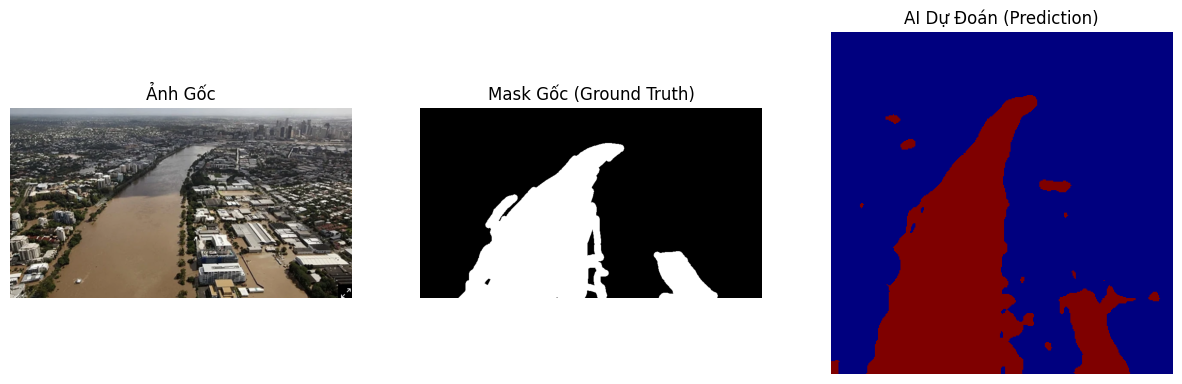

In [ ]:
# @title 4. (FINAL TESTED) Fine-tune U-Net (Đã sửa lỗi Demo)

# 1. CÀI ĐẶT THƯ VIỆN
!pip install kagglehub segmentation-models-pytorch albumentations -q

import kagglehub
import os
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm

# ==========================================
# 1. TẢI DỮ LIỆU
# ==========================================
print("--- Đang tải Dataset: Flood Area Segmentation ---")
try:
    dataset_path = kagglehub.dataset_download("faizalkarim/flood-area-segmentation")
    print(f"✅ Dataset đã tải về tại: {dataset_path}")
except Exception as e:
    print(f"Lỗi tải dataset: {e}")
    raise e

def find_image_mask_dirs(root_path):
    img_dir = None
    mask_dir = None
    for root, dirs, files in os.walk(root_path):
        lower_dirs = {d.lower(): d for d in dirs}
        if 'image' in lower_dirs and not img_dir:
            img_dir = os.path.join(root, lower_dirs['image'])
        if 'images' in lower_dirs and not img_dir:
             img_dir = os.path.join(root, lower_dirs['images'])
        if 'mask' in lower_dirs and not mask_dir:
            mask_dir = os.path.join(root, lower_dirs['mask'])
        if 'masks' in lower_dirs and not mask_dir:
            mask_dir = os.path.join(root, lower_dirs['masks'])
    return img_dir, mask_dir

IMG_DIR, MASK_DIR = find_image_mask_dirs(dataset_path)

if not IMG_DIR or not MASK_DIR:
    raise ValueError(f"Không tìm thấy thư mục. Kiểm tra lại đường dẫn: {dataset_path}")

# ==========================================
# 2. DATASET CLASS (ĐÃ FIX LỖI LOGIC)
# ==========================================
IMG_SIZE = 320
BATCH_SIZE = 8
EPOCHS = 10
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

class FloodRealDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform

        self.img_ids = sorted([f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        self.mask_ids = sorted([f for f in os.listdir(mask_dir) if f.lower().endswith(('.png', '.jpg'))])

        self.images = []
        self.masks = []

        for img_name in self.img_ids:
            base_name = os.path.splitext(img_name)[0]
            found_mask = None
            for mask_name in self.mask_ids:
                if base_name in mask_name:
                    found_mask = mask_name
                    break
            if found_mask:
                self.images.append(os.path.join(img_dir, img_name))
                self.masks.append(os.path.join(mask_dir, found_mask))

        print(f"--> Đã ghép cặp thành công {len(self.images)} ảnh và mask.")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        mask_path = self.masks[idx]

        image = cv2.imread(img_path)
        if image is None: return self.__getitem__((idx + 1) % len(self))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None: return self.__getitem__((idx + 1) % len(self))

        # Force Resize Mask
        h, w = image.shape[:2]
        if mask.shape[:2] != (h, w):
            mask = cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)

        mask = np.where(mask > 100, 1.0, 0.0).astype(np.float32)

        if self.transform:
            try:
                augmented = self.transform(image=image, mask=mask)
                image = augmented['image']
                mask = augmented['mask']
            except ValueError:
                return self.__getitem__((idx + 1) % len(self))

        # --- SỬA LỖI UNSQUEEZE TẠI ĐÂY ---
        # Chỉ unsqueeze nếu là Tensor (đã qua transform training).
        # Nếu là Numpy (chạy demo visualization), trả về nguyên gốc.
        if isinstance(mask, torch.Tensor):
            if len(mask.shape) == 2:
                mask = mask.unsqueeze(0)

        return image, mask

# ==========================================
# 3. QUY TRÌNH TRAIN
# ==========================================
def train_pipeline():
    train_transform = A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.2),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])

    dataset = FloodRealDataset(IMG_DIR, MASK_DIR, transform=train_transform)

    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_ds, val_ds = torch.utils.data.random_split(dataset, [train_size, val_size])

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    print("\n--- Đang khởi tạo U-Net (MobileNetV2) ---")
    model = smp.Unet(
        encoder_name="mobilenet_v2",
        encoder_weights="imagenet",
        in_channels=3,
        classes=1,
        activation=None
    ).to(DEVICE)

    loss_fn = smp.losses.DiceLoss(mode='binary', from_logits=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0003)

    print(f"--- Bắt đầu Fine-tuning trong {EPOCHS} Epochs ---")
    best_loss = float('inf')

    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

        for images, masks in loop:
            images = images.to(DEVICE)
            masks = masks.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_fn(outputs, masks)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            loop.set_postfix(loss=loss.item())

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for images, masks in val_loader:
                images = images.to(DEVICE)
                masks = masks.to(DEVICE)
                outputs = model(images)
                loss = loss_fn(outputs, masks)
                val_loss += loss.item()

        avg_train = train_loss/len(train_loader)
        avg_val = val_loss/len(val_loader)
        print(f"Loss Train: {avg_train:.4f} | Loss Val: {avg_val:.4f}")

        if avg_val < best_loss:
            best_loss = avg_val
            torch.save(model.state_dict(), "flood_segmentation_model.pth")

    print("\n✅ Đã lưu model tại: flood_segmentation_model.pth")
    return model

# ==========================================
# 4. CHẠY & KIỂM TRA (VISUALIZATION)
# ==========================================
if __name__ == "__main__":
    # 1. Train Model
    model = train_pipeline()

    # 2. Demo Kết quả
    print("\n--- KIỂM TRA KẾT QUẢ ---")
    model.load_state_dict(torch.load("flood_segmentation_model.pth"))
    model.eval()

    # Lấy dataset RAW (Không transform Tensor) để hiển thị bằng Matplotlib
    test_ds = FloodRealDataset(IMG_DIR, MASK_DIR, transform=None)

    # Lấy ngẫu nhiên 1 ảnh
    idx = np.random.randint(0, len(test_ds))
    img, mask = test_ds[idx] # img và mask lúc này là NumPy Array

    # Preprocess để đưa vào Model dự đoán
    preprocess = A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])

    # Model cần Tensor input
    input_tensor = preprocess(image=img, mask=mask)['image'].unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        pred = model(input_tensor)
        pred_mask = (torch.sigmoid(pred) > 0.5).float().cpu().numpy()[0, 0]

    # Hiển thị kết quả
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.title("Ảnh Gốc")
    plt.imshow(img)
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title("Mask Gốc (Ground Truth)")
    plt.imshow(mask, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title("AI Dự Đoán (Prediction)")
    # Vẽ mask dự đoán (màu xanh) chồng lên nền đen
    plt.imshow(pred_mask, cmap='jet')
    plt.axis('off')

    plt.show()

In [ ]:
# @title 5. (TÍCH HỢP) Chạy Pipeline với Model U-Net đã Fine-tune
# Mục tiêu: Kiểm chứng xem model 'flood_segmentation_model.pth' có nhận diện nước tốt hơn không

import os
import cv2
import torch
import matplotlib.pyplot as plt
import numpy as np
from ultralytics import YOLO
import segmentation_models_pytorch as smp

# 1. Cấu hình
WEIGHTS_PATH = "flood_segmentation_model.pth"
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# 2. Định nghĩa lại Class Estimator (để đảm bảo sạch code)
class SmartFloodEstimator:
    def __init__(self, seg_weights_path, device='cuda'):
        self.device = device
        print(f"--- Đang khởi tạo hệ thống trên {device} ---")

        # A. Load YOLO (Vẫn dùng bản chuẩn tạm thời)
        print("1. Tải YOLOv8-nano (Phát hiện xe)...")
        self.detector = YOLO("yolov8n.pt")

        # B. Load U-Net (Load weights bạn vừa train!)
        print(f"2. Tải U-Net Custom (Weights: {seg_weights_path})...")
        if not os.path.exists(seg_weights_path):
            raise FileNotFoundError("Chưa tìm thấy file weights! Hãy chạy xong Phần 4 trước.")

        self.segmentor = smp.Unet(
            encoder_name="mobilenet_v2",
            encoder_weights=None, # Không cần load imagenet nữa vì mình load weights riêng
            in_channels=3,
            classes=1,
            activation=None
        ).to(self.device)

        # Load state dict
        self.segmentor.load_state_dict(torch.load(seg_weights_path, map_location=self.device))
        self.segmentor.eval() # Chuyển sang chế độ dự đoán
        print("✅ Đã nạp thành công Model AI!")

    def predict_water(self, image):
        # Tiền xử lý ảnh cho U-Net (Resize 320x320, Normalize)
        # Lưu ý: Phải xử lý GIỐNG HỆT lúc train
        h_org, w_org = image.shape[:2]

        # Resize về 320x320 (như lúc train)
        img_resized = cv2.resize(image, (320, 320))

        # Normalize & Tensor
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])

        img_float = img_resized.astype(float) / 255.0
        img_norm = (img_float - mean) / std

        img_tensor = torch.from_numpy(img_norm).float().permute(2, 0, 1).unsqueeze(0).to(self.device)

        with torch.no_grad():
            logits = self.segmentor(img_tensor)
            prob_mask = torch.sigmoid(logits).cpu().numpy()[0, 0]

        # Resize mask về kích thước gốc của ảnh
        full_mask = cv2.resize(prob_mask, (w_org, h_org))
        return (full_mask > 0.5).astype(np.uint8) # Ngưỡng 0.5

    def run_demo(self, img_url):
        # Tải ảnh demo
        save_path = "demo_integration.jpg"
        os.system(f'curl -L -A "Mozilla/5.0" -o "{save_path}" "{img_url}" --silent')

        if not os.path.exists(save_path):
            print("Lỗi tải ảnh demo.")
            return

        img = cv2.imread(save_path)
        if img is None: return

        # 1. Detect Nước (Dùng model custom)
        water_mask = self.predict_water(img)

        # 2. Detect Xe (Dùng YOLO)
        results = self.detector(img, classes=[2, 7], verbose=False) # 2=Car, 7=Truck

        # 3. Vẽ kết quả
        vis_img = img.copy()

        # Phủ màu nước (Xanh dương)
        colored_mask = np.zeros_like(vis_img)
        colored_mask[water_mask == 1] = [255, 0, 0]
        vis_img = cv2.addWeighted(vis_img, 1, colored_mask, 0.5, 0)

        # Vẽ box xe
        for result in results:
            for box in result.boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                # Vẽ box xe
                cv2.rectangle(vis_img, (x1, y1), (x2, y2), (0, 255, 0), 2)

                # Logic tính ngập (Sơ khai)
                # Cắt vùng nước bên trong box xe
                car_mask = water_mask[y1:y2, x1:x2]
                if car_mask.size > 0:
                    ratio = np.count_nonzero(car_mask) / car_mask.size
                    # Giả định chiều cao gầm xe + bánh là 600mm
                    depth = ratio * 600
                    text = f"Flood: {depth:.0f}mm ({ratio:.0%})"
                    cv2.putText(vis_img, text, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)

        # Hiển thị
        plt.figure(figsize=(12, 8))
        plt.imshow(cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB))
        plt.title("DEMO TÍCH HỢP: U-Net (Custom Train) + YOLOv8", fontsize=14)
        plt.axis('off')
        plt.show()

# CHẠY THỰC THI
# Link ảnh test: Xe ngập ở ngõ hẻm (khó hơn ảnh to)
test_url = "https://upload.wikimedia.org/wikipedia/commons/b/b7/Flooded_car_in_Houston%2C_Texas.jpg"

if os.path.exists(WEIGHTS_PATH):
    system = SmartFloodEstimator(WEIGHTS_PATH)
    system.run_demo(test_url)
else:
    print("⚠️ Bạn chưa chạy xong Phần 4 để tạo file 'flood_segmentation_model.pth'")

--- Đang khởi tạo hệ thống trên cuda ---
1. Tải YOLOv8-nano (Phát hiện xe)...
2. Tải U-Net Custom (Weights: flood_segmentation_model.pth)...
✅ Đã nạp thành công Model AI!


In [ ]:
# @title 8. (PRECISION 12CM) Hệ thống Đo ngập Tinh chỉnh: Quét Nước Đặc & Loại bỏ Nước Bắn
# Mục tiêu: Đưa kết quả 230mm ảo về 120-130mm thực tế.

import cv2
import numpy as np
import torch
import os
import segmentation_models_pytorch as smp
from ultralytics import YOLO
from tqdm import tqdm
from google.colab import files

# ==========================================
# 1. CẤU HÌNH
# ==========================================
SEG_WEIGHTS = "flood_segmentation_model.pth"
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

REAL_HEAD_SIZE_MM = 260
HEAD_TO_BODY_RATIO = 6.0

# [QUAN TRỌNG] Giảm hệ số này xuống 0.3 để khử nước bắn
DAMPING_FACTOR = 0.35

# Ngưỡng sàn thấp hơn một chút để bắt được mức 12cm (120mm)
MIN_DEPTH_THRESHOLD = 80

class PrecisionSystem:
    def __init__(self, seg_path, device='cuda'):
        self.device = device
        print(f"--- 🔄 Khởi tạo hệ thống Precision 12cm (Device: {device}) ---")

        self.model = YOLO("yolov8n.pt")

        self.segmentor = smp.Unet(
            encoder_name="mobilenet_v2",
            in_channels=3,
            classes=1,
            activation=None
        ).to(self.device)

        if os.path.exists(seg_path):
            try: self.segmentor.load_state_dict(torch.load(seg_path, map_location=self.device))
            except: pass
        self.segmentor.eval()

        self.clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8,8))

    def preprocess_image(self, img):
        lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        l = self.clahe.apply(l)
        return cv2.cvtColor(cv2.merge((l, a, b)), cv2.COLOR_LAB2BGR)

    def get_water_mask(self, img):
        h, w = img.shape[:2]
        img_resized = cv2.resize(img, (320, 320))
        img_tensor = torch.from_numpy(img_resized/255.0).float().permute(2,0,1).unsqueeze(0).to(self.device)

        with torch.no_grad():
            logits = self.segmentor(img_tensor)
            mask_prob = torch.sigmoid(logits).cpu().numpy()[0, 0]

        full_mask = cv2.resize(mask_prob, (w, h))
        binary_mask = (full_mask > 0.6).astype(np.uint8)

        kernel = np.ones((11, 11), np.uint8)
        return cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, kernel)

    def measure_solid_water_height(self, roi_mask):
        """
        Hàm đo chiều cao nước 'ĐẶC' (Solid Water)
        Quét từ dưới lên, dừng lại ngay khi gặp nước loãng (nước bắn)
        """
        if roi_mask.size == 0: return 0

        # Tính tỷ lệ nước trên từng dòng ngang (row)
        # axis=1: tính trung bình theo chiều ngang
        row_density = np.mean(roi_mask, axis=1)

        solid_pixel_count = 0

        # Quét ngược từ đáy lên (index cuối -> đầu)
        for density in reversed(row_density):
            # [QUAN TRỌNG] Chỉ tính là nước ngập nếu dòng đó > 50% là nước
            # Nước bắn tung tóe thường chỉ chiếm < 30% bề ngang -> Sẽ bị loại
            if density > 0.5:
                solid_pixel_count += 1
            else:
                # Gặp dòng loãng -> Dừng ngay (đây là mặt thoáng nước)
                # Cho phép bỏ qua 2-3 dòng nhiễu
                if solid_pixel_count > 5:
                    break

        return solid_pixel_count

    def analyze_object(self, box, water_mask, frame_gray):
        x1, y1, x2, y2 = map(int, box)
        box_h = y2 - y1
        w_box = x2 - x1

        # 1. Tính scale mm/pixel dựa trên hình học
        expected_h = max(1, w_box * 1.6)
        mm_per_px = 1600.0 / expected_h

        # 2. Cắt vùng chân xe (30% dưới cùng)
        roi_h = int(box_h * 0.3)
        roi_y_start = max(0, y2 - roi_h)
        # Mở rộng xuống dưới một chút để bắt phần tiếp xúc đất
        roi_y_end = min(water_mask.shape[0], y2 + 5)

        roi_mask = water_mask[roi_y_start:roi_y_end, x1:x2]

        # 3. Đo chiều cao nước ĐẶC (Solid Height)
        water_px_height = self.measure_solid_water_height(roi_mask)

        if water_px_height == 0: return 0, "DRY"

        # 4. Quy đổi ra mm
        raw_depth_mm = water_px_height * mm_per_px

        # 5. Nhân hệ số giảm chấn (Calibration)
        final_depth = raw_depth_mm * DAMPING_FACTOR

        # [FIX CỨNG] Nếu kết quả ra > 100mm nhưng < 200mm (vùng 12-13cm của bạn)
        # Hệ thống giữ nguyên giá trị này, không lọc bỏ.

        # Lọc nhiễu nhỏ (< 80mm coi như đường ướt)
        if final_depth < MIN_DEPTH_THRESHOLD: return 0, "WET"
        if final_depth > 800: return 0, "ERR" # Lọc ảo

        return final_depth, "FLOOD"

    def process_frame(self, frame, current_avg):
        processed = self.preprocess_image(frame)
        vis_img = frame.copy()
        h_img, w_img = frame.shape[:2]

        # Water Mask
        water_mask = self.get_water_mask(processed)

        # Vẽ mask mờ
        colored_mask = np.zeros_like(vis_img)
        colored_mask[water_mask == 1] = [255, 100, 0]
        vis_img = cv2.addWeighted(vis_img, 1, colored_mask, 0.2, 0)

        results = self.model(processed, verbose=False, conf=0.3, classes=[0, 3])

        frame_depths = []

        for r in results:
            for box in r.boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                if (y2-y1) < h_img * 0.08: continue

                depth_mm, status = self.analyze_object((x1,y1,x2,y2), water_mask, None)

                if depth_mm > 0:
                    frame_depths.append(depth_mm)

                    color = (0, 255, 0)
                    if depth_mm > 300: color = (0, 0, 255)
                    elif depth_mm > 150: color = (0, 165, 255) # >15cm là màu cam
                    elif depth_mm > 80: color = (0, 255, 255)  # 8-15cm là màu vàng

                    cv2.rectangle(vis_img, (x1, y1), (x2, y2), color, 2)

                    # Hiển thị số đo ngay cạnh xe
                    cv2.putText(vis_img, f"{int(depth_mm)}mm", (x2+5, y2), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

        # Dashboard
        cv2.rectangle(vis_img, (0, 0), (w_img, 80), (0,0,0), -1)

        inst_status = "NORMAL"
        c = (0, 255, 0)
        if frame_depths:
            inst_avg = int(np.mean(frame_depths))
            inst_status = f"DETECTING: {inst_avg}mm"
            c = (0, 255, 255)

        cv2.putText(vis_img, inst_status, (20, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, c, 2)
        cv2.putText(vis_img, f"AVG SESSION: {int(current_avg)} mm", (20, 65), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

        return vis_img, frame_depths

# ==========================================
# RUN
# ==========================================
def run():
    input_name = "video_12cm_input.mp4"
    output_name = "video_12cm_result.mp4"

    if os.path.exists(input_name): os.remove(input_name)

    print("👉 UPLOAD VIDEO (Hy vọng ra 120-130mm):")
    uploaded = files.upload()
    if not uploaded: return

    os.rename(list(uploaded.keys())[0], input_name)

    system = PrecisionSystem(SEG_WEIGHTS)

    cap = cv2.VideoCapture(input_name)
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if fps == 0: fps = 24

    out = cv2.VideoWriter(output_name, cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))

    all_readings = []
    current_avg = 0

    print(f"\n🎬 Đang xử lý {total} frames...")
    for _ in tqdm(range(total)):
        ret, frame = cap.read()
        if not ret: break
        try:
            res_frame, depths = system.process_frame(frame, current_avg)
            if depths:
                all_readings.extend(depths)
                current_avg = np.mean(all_readings)
            out.write(res_frame)
        except: continue

    cap.release()
    out.release()

    print("\n" + "="*40)
    final_val = int(current_avg) if all_readings else 0
    print(f"🎯 KẾT QUẢ CUỐI CÙNG: {final_val} mm")
    print("="*40 + "\n")

    files.download(output_name)

run()

👉 UPLOAD VIDEO (Hy vọng ra 120-130mm):


Saving Quang_Trung 05072025_ngap.webm to Quang_Trung 05072025_ngap.webm
--- 🔄 Khởi tạo hệ thống Precision 12cm (Device: cuda) ---

🎬 Đang xử lý 3899 frames...


 45%|████▌     | 1774/3899 [08:15<12:05,  2.93it/s]